In [47]:
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

In [48]:
with open('globIter.txt', "r") as f:
	globLines = f.readlines()
with open('globPot.txt', "r") as f:
	globPotLines = f.readlines()
with open('globErr.txt', "r") as f:
	globErrLines = f.readlines()
with open('locIter.txt', "r") as f:
	locLines = f.readlines()

In [49]:
glob1y = np.fromstring(globLines[0].strip(), sep='\t')[1:]
glob1x = np.linspace(1, len(glob1y), len(glob1y))

glob2y = np.fromstring(globLines[1].strip(), sep='\t')[1:]
glob2x = np.linspace(1, len(glob2y), len(glob2y))

globPot = [
    np.array([list(map(np.double, row.strip().split(" "))) for row in globPotLines[:151]]).transpose(),
    np.array([list(map(np.double, row.strip().split(" "))) for row in globPotLines[152:303]]).transpose()
]
globErr = [
    np.array([list(map(np.double, row.strip().split(" "))) for row in globErrLines[:151]]).transpose(),
    np.array([list(map(np.double, row.strip().split(" "))) for row in globErrLines[152:303]]).transpose()
]

In [50]:
loc1y = np.fromstring(locLines[0], sep='\t')[1:]
loc1x = np.linspace(1, len(loc1y), len(loc1y))

loc2y = np.fromstring(locLines[1], sep='\t')[1:]
loc2x = np.linspace(1, len(loc2y), len(loc2y))

loc3y = np.fromstring(locLines[2], sep='\t')[1:]
loc3x = np.linspace(1, len(loc3y), len(loc3y))

loc4y = np.fromstring(locLines[3], sep='\t')[1:]
loc4x = np.linspace(1, len(loc4y), len(loc4y))

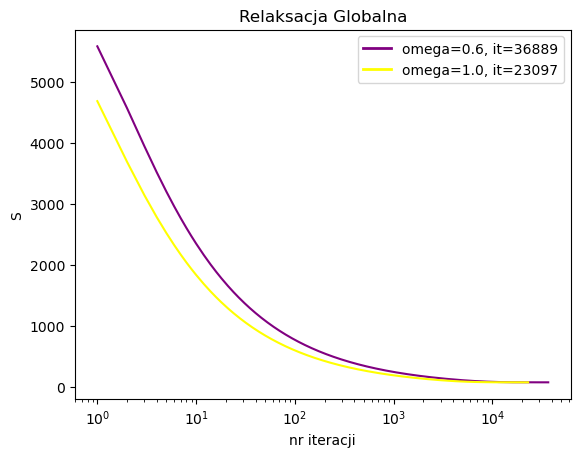

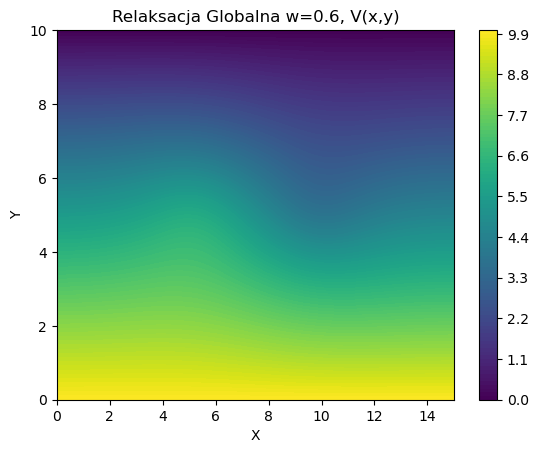

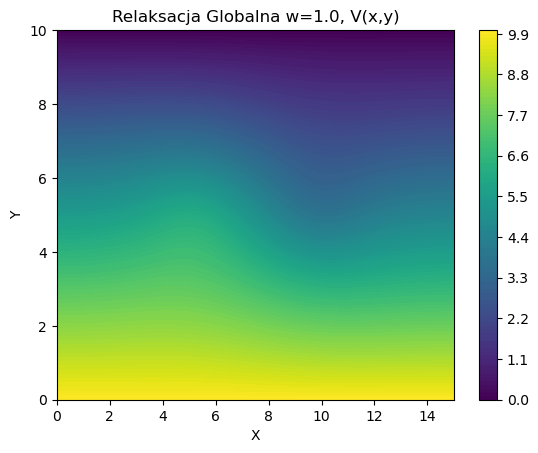

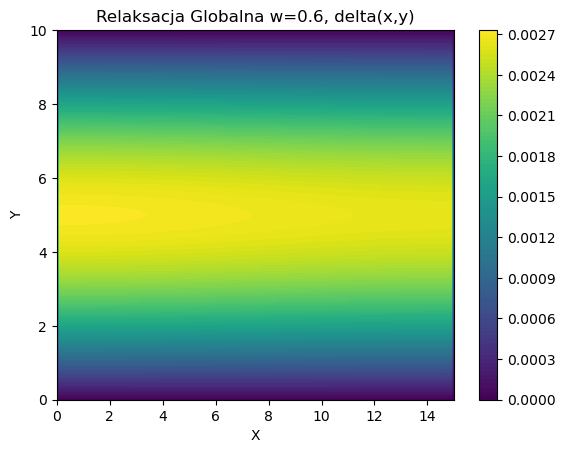

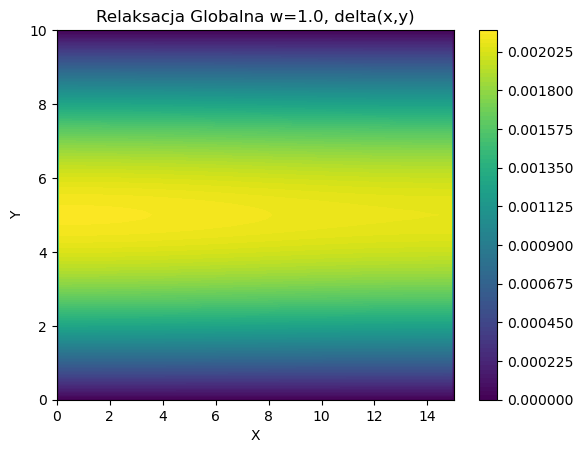

In [51]:
globColors = ("purple", "yellow")
plt.plot(glob1x, glob1y, color=globColors[0])
plt.plot(glob2x, glob2y, color=globColors[1])

omega = ("0.6", "1.0")

legend_handles = [
    Line2D([0], [0], color=globColors[0], lw=2, label=f'omega={omega[0]}, it={len(glob1y)}'),
    Line2D([0], [0], color=globColors[1], lw=2, label=f'omega={omega[1]}, it={len(glob2y)}'),
]

plt.title("Relaksacja Globalna")
plt.legend(loc="upper right", handles=legend_handles)
plt.xscale("log")
plt.xlabel("nr iteracji")
plt.ylabel("S")
plt.savefig(f"relGlobPlotS.jpg")
plt.show()

X, Y = np.meshgrid(np.linspace(0, 15, 151), np.linspace(0, 10, 101))

for i, pot in enumerate(globPot):
    plt.contourf(X, Y, pot, cmap='viridis', levels=100)
    plt.title(f'Relaksacja Globalna w={omega[i]}, V(x,y)')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.colorbar()
    plt.savefig(f"relGlobPlotV{omega[i]}.jpg")
    plt.show()

for i, pot in enumerate(globErr):
    plt.contourf(X, Y, pot, cmap='viridis', levels=100)
    plt.title(f'Relaksacja Globalna w={omega[i]}, delta(x,y)')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.colorbar()
    plt.savefig(f"relGlobPlotW{omega[i]}.jpg")
    plt.show()

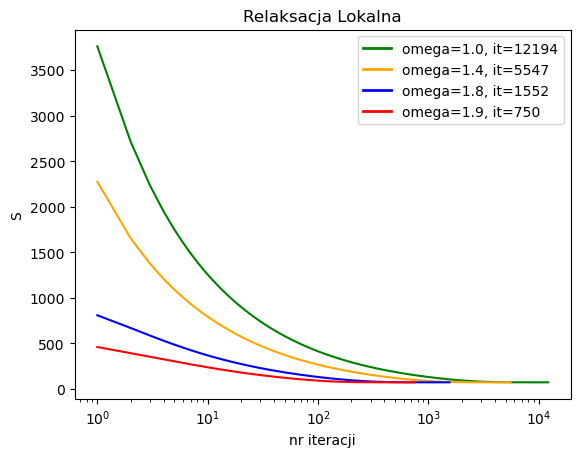

In [52]:
locColors = ("green", "orange", "blue", "red")
plt.plot(loc1x, loc1y, color=locColors[0])
plt.plot(loc2x, loc2y, color=locColors[1])
plt.plot(loc3x, loc3y, color=locColors[2])
plt.plot(loc4x, loc4y, color=locColors[3])

omega = ("1.0", "1.4", "1.8", "1.9")

legend_handles = [
    Line2D([0], [0], color=locColors[0], lw=2, label=f'omega={omega[0]}, it={len(loc1y)}'),
    Line2D([0], [0], color=locColors[1], lw=2, label=f'omega={omega[1]}, it={len(loc2y)}'),
    Line2D([0], [0], color=locColors[2], lw=2, label=f'omega={omega[2]}, it={len(loc3y)}'),
    Line2D([0], [0], color=locColors[3], lw=2, label=f'omega={omega[3]}, it={len(loc4y)}'),
]

plt.title("Relaksacja Lokalna")
plt.legend(loc="upper right", handles=legend_handles)
plt.xscale("log")
plt.xlabel("nr iteracji")
plt.ylabel("S")
plt.savefig(f"locGlobPlotS.jpg")
plt.show()